In [1]:
from google.colab import files
uploaded = files.upload()
# Select all 6 CSV files at once

Saving 01_awareness_data.csv to 01_awareness_data.csv
Saving 02_consideration_data.csv to 02_consideration_data.csv
Saving 03_intent_data.csv to 03_intent_data.csv
Saving 04_conversion_data.csv to 04_conversion_data.csv
Saving 05_retention_data.csv to 05_retention_data.csv
Saving 06_full_funnel_summary.csv to 06_full_funnel_summary.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'awareness':     '#1A5276',
    'consideration': '#2E86C1',
    'intent':        '#85C1E9',
    'conversion':    '#27AE60',
    'retention':     '#E74C3C'
}

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [3]:
awareness     = pd.read_csv('01_awareness_data.csv',     parse_dates=['date'])
consideration = pd.read_csv('02_consideration_data.csv', parse_dates=['date'])
intent        = pd.read_csv('03_intent_data.csv',        parse_dates=['date'])
conversion    = pd.read_csv('04_conversion_data.csv',    parse_dates=['date'])
retention     = pd.read_csv('05_retention_data.csv',     parse_dates=['date'])
funnel        = pd.read_csv('06_full_funnel_summary.csv',parse_dates=['date'])

print("✅ All datasets loaded!")
print(f"Date range: {funnel['date'].min().date()} to {funnel['date'].max().date()}")
print(f"Total weeks: {len(funnel)}")
print(f"\nDataset shapes:")
for name, df in [('Awareness', awareness), ('Consideration', consideration),
                  ('Intent', intent), ('Conversion', conversion),
                  ('Retention', retention), ('Summary', funnel)]:
    print(f"  {name:15} {df.shape}")

✅ All datasets loaded!
Date range: 2023-01-02 to 2024-12-23
Total weeks: 104

Dataset shapes:
  Awareness       (104, 11)
  Consideration   (104, 10)
  Intent          (104, 9)
  Conversion      (104, 10)
  Retention       (104, 11)
  Summary         (104, 22)


#  Funnel Summary Table:

In [4]:
funnel_summary = pd.DataFrame({
    'Stage':       ['Awareness', 'Consideration', 'Intent',
                    'Conversion', 'Retention'],
    'Key Metric':  ['Impressions', 'Website Visits', 'Trial Signups',
                    'New Customers', 'Active Customers'],
    'Avg Weekly':  [
        f"{funnel['impressions'].mean():,.0f}",
        f"{funnel['website_visits'].mean():,.0f}",
        f"{funnel['trial_signups'].mean():,.0f}",
        f"{funnel['new_customers'].mean():,.0f}",
        f"{funnel['active_customers'].mean():,.0f}"
    ],
    'Key KPI':     [
        f"{funnel['brand_lift_pct'].mean():.1f}% Brand Lift",
        f"{funnel['bounce_rate'].mean():.1f}% Bounce Rate",
        f"{funnel['trial_rate_pct'].mean():.1f}% Trial Rate",
        f"{funnel['trial_to_paid_pct'].mean():.1f}% Trial→Paid",
        f"{funnel['churn_rate_pct'].mean():.1f}% Churn Rate"
    ],
    'Avg Spend':   [
        f"${funnel['awareness_spend'].mean():,.0f}",
        f"${funnel['consideration_spend'].mean():,.0f}",
        f"${funnel['intent_spend'].mean():,.0f}",
        f"${funnel['total_spend'].mean():,.0f}",
        'N/A'
    ]
})

print("=" * 70)
print("FULL FUNNEL SUMMARY — COMPANY A SAAS PLATFORM")
print("=" * 70)
print(funnel_summary.to_string(index=False))

FULL FUNNEL SUMMARY — COMPANY A SAAS PLATFORM
        Stage       Key Metric Avg Weekly           Key KPI Avg Spend
    Awareness      Impressions  6,638,815  25.0% Brand Lift   $47,816
Consideration   Website Visits    271,569 50.3% Bounce Rate   $38,021
       Intent    Trial Signups     33,685  12.0% Trial Rate    $8,053
   Conversion    New Customers      7,066  19.8% Trial→Paid   $93,890
    Retention Active Customers    397,483   4.0% Churn Rate       N/A


#  Plot 1: Funnel Volume Chart:


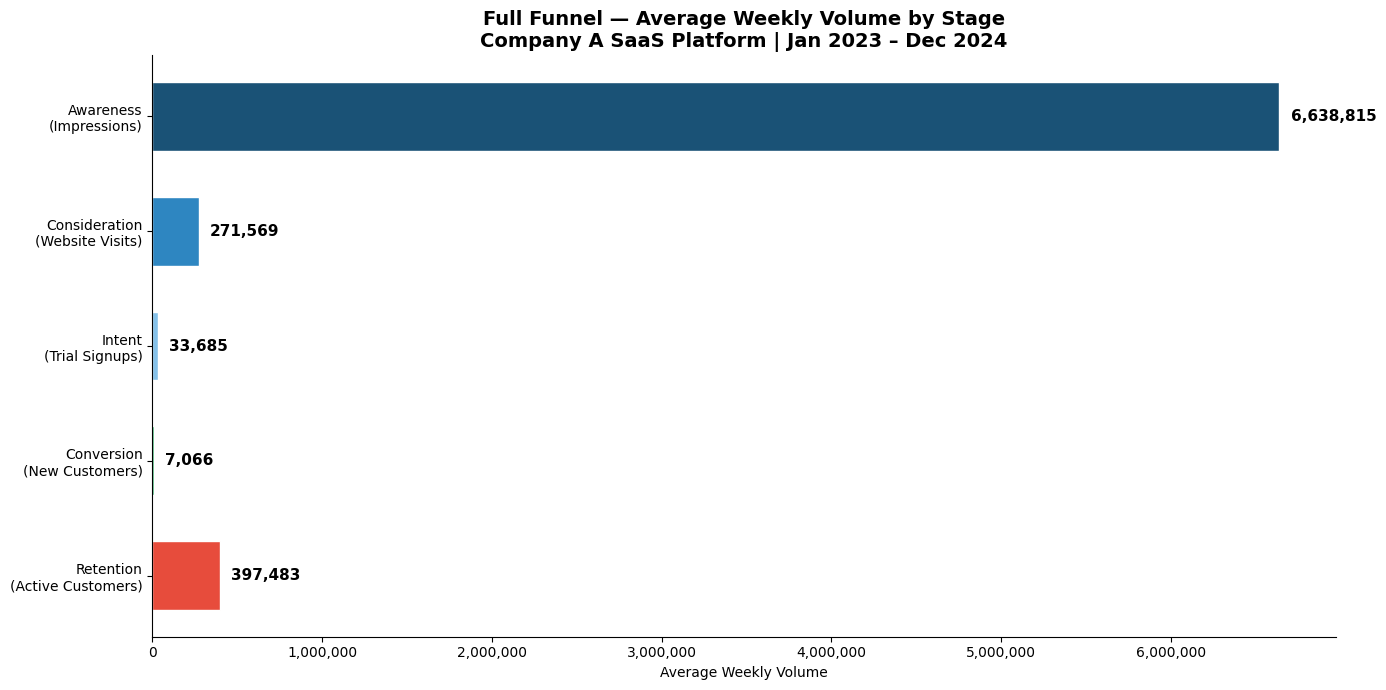

✅ Plot 1 saved!


In [9]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(stages[::-1], avg_stages[::-1],
               color=colors[::-1], edgecolor='white', height=0.6)

for bar, val in zip(bars, avg_stages[::-1]):
    ax.text(bar.get_width() + max(avg_stages) * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontweight='bold', fontsize=11)

ax.set_title('Full Funnel — Average Weekly Volume by Stage\nCompany A SaaS Platform | Jan 2023 – Dec 2024',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Weekly Volume')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('01_funnel_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved!")

#  Plot 2: Funnel Conversion Rates:


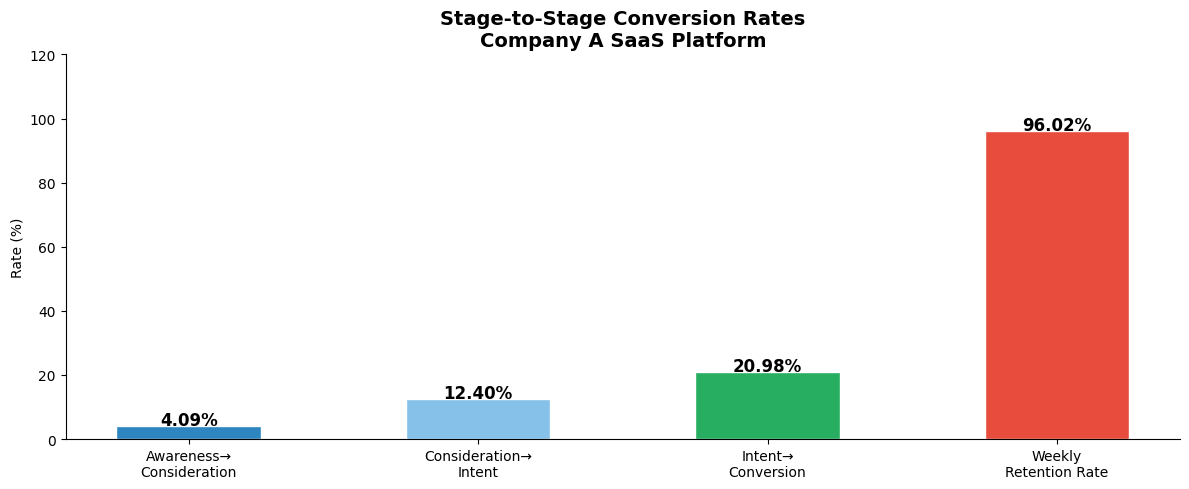

✅ Plot 2 fixed and saved!


In [18]:
from matplotlib.ticker import FuncFormatter

# Correct conversion rates
conv_rates = [
    funnel['website_visits'].mean() / funnel['impressions'].mean() * 100,
    funnel['trial_signups'].mean() / funnel['website_visits'].mean() * 100,
    funnel['new_customers'].mean() / funnel['trial_signups'].mean() * 100,
    100 - funnel['churn_rate_pct'].mean()  # Retention rate = 1 - churn
]

conv_labels = ['Awareness→\nConsideration',
               'Consideration→\nIntent',
               'Intent→\nConversion',
               'Weekly\nRetention Rate']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(conv_labels, conv_rates,
              color=[COLORS['consideration'], COLORS['intent'],
                     COLORS['conversion'], COLORS['retention']],
              width=0.5, edgecolor='white')

for bar, val in zip(bars, conv_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Stage-to-Stage Conversion Rates\nCompany A SaaS Platform',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.set_ylim(0, max(conv_rates) * 1.25)

plt.tight_layout()
plt.savefig('02_conversion_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 fixed and saved!")

# Plot 3: Full Funnel Trends Over Time:


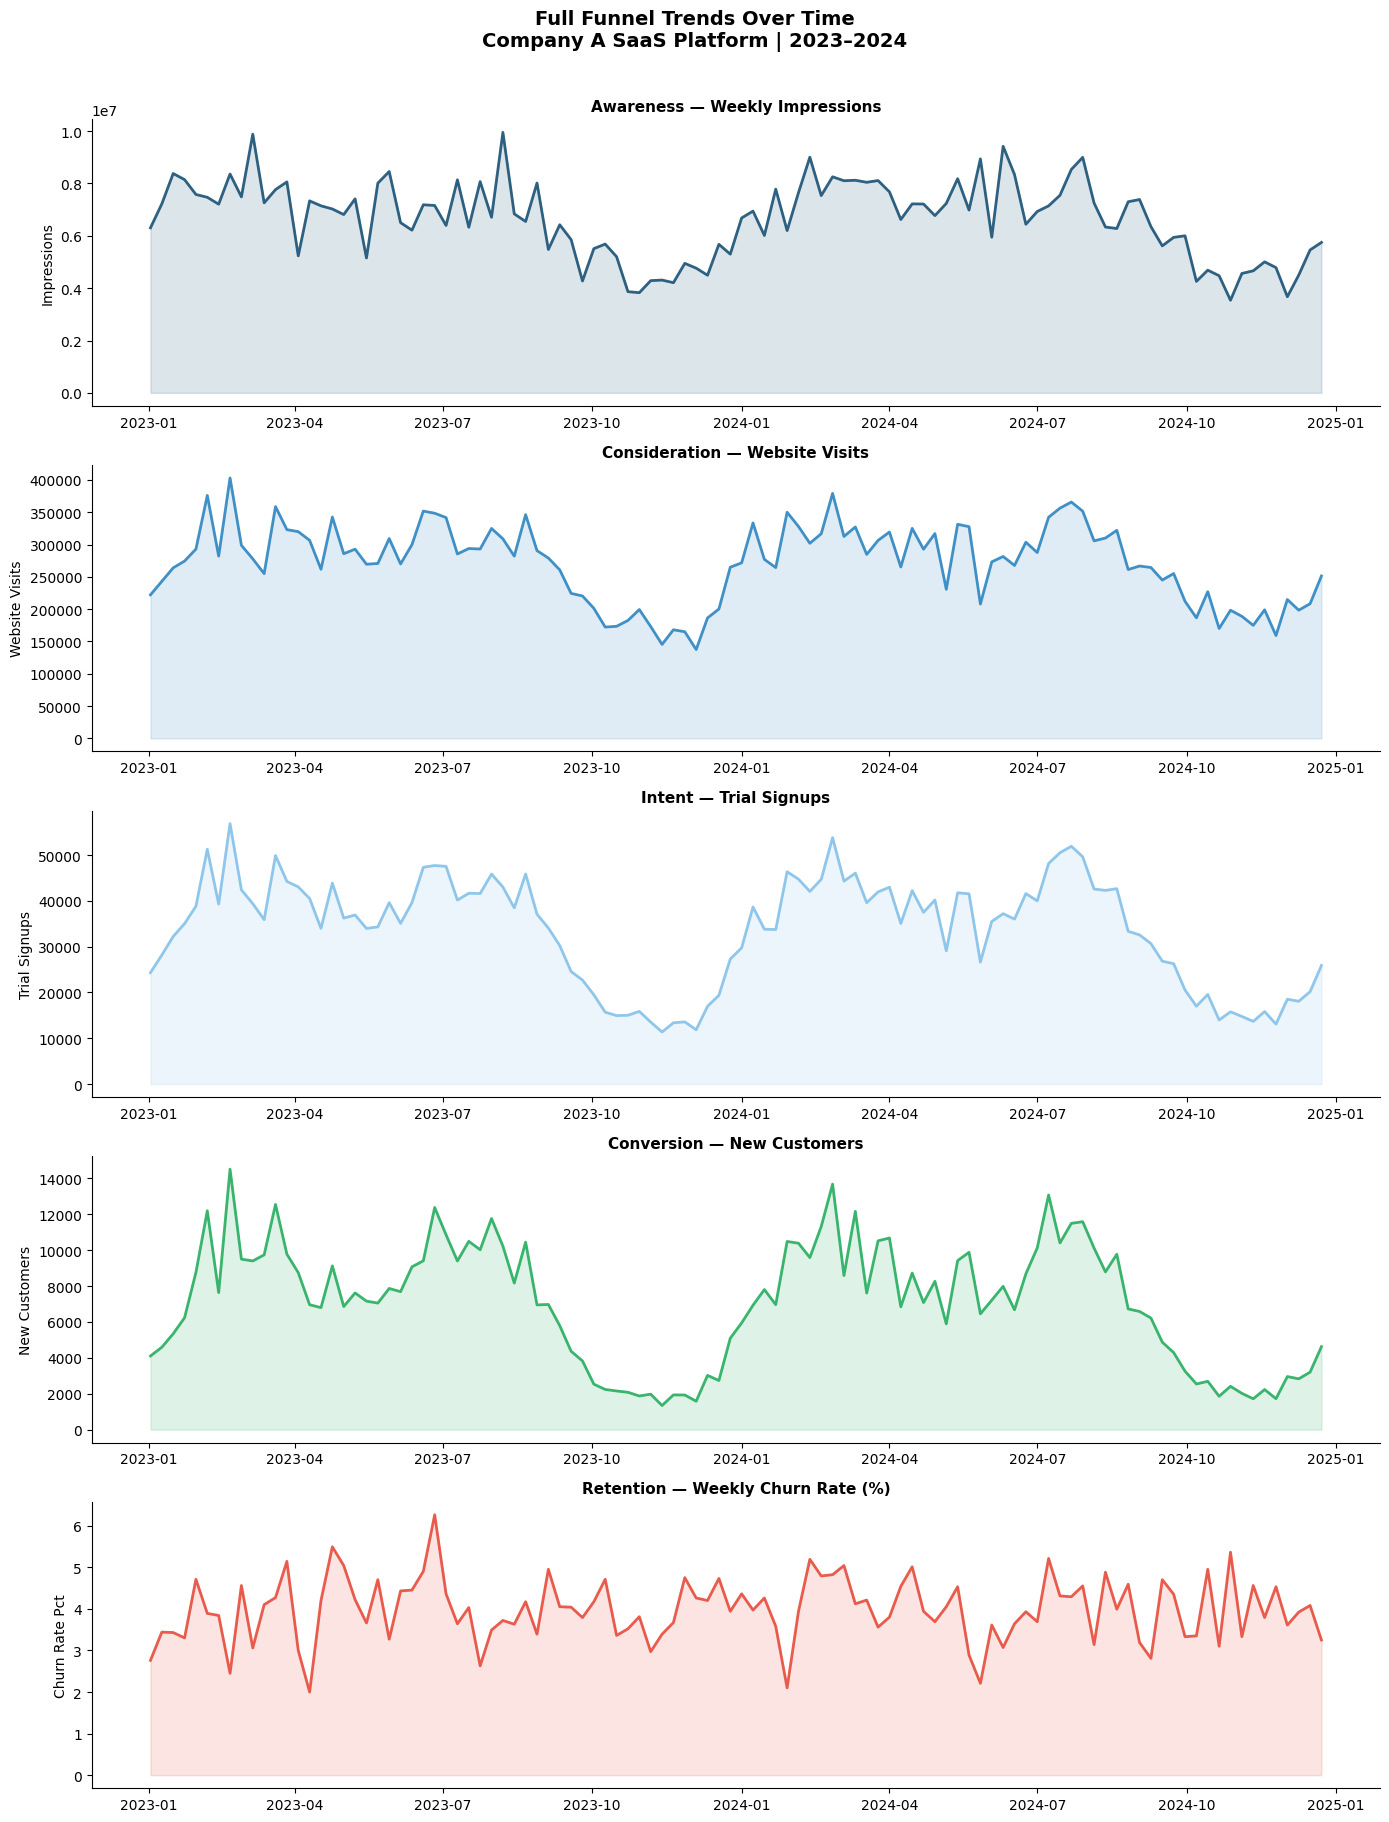

✅ Plot 3 saved!


In [11]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))
fig.suptitle('Full Funnel Trends Over Time\nCompany A SaaS Platform | 2023–2024',
             fontsize=14, fontweight='bold', y=1.01)

metrics = [
    ('impressions',      'Awareness — Weekly Impressions',      COLORS['awareness']),
    ('website_visits',   'Consideration — Website Visits',      COLORS['consideration']),
    ('trial_signups',    'Intent — Trial Signups',              COLORS['intent']),
    ('new_customers',    'Conversion — New Customers',          COLORS['conversion']),
    ('churn_rate_pct',   'Retention — Weekly Churn Rate (%)',   COLORS['retention'])
]

for ax, (col, title, color) in zip(axes, metrics):
    ax.plot(funnel['date'], funnel[col],
            color=color, linewidth=2, alpha=0.9)
    ax.fill_between(funnel['date'], funnel[col],
                    alpha=0.15, color=color)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(col.replace('_', ' ').title())

plt.tight_layout()
plt.savefig('03_funnel_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 saved!")

#  Plot 4: Spend Distribution by Stage:

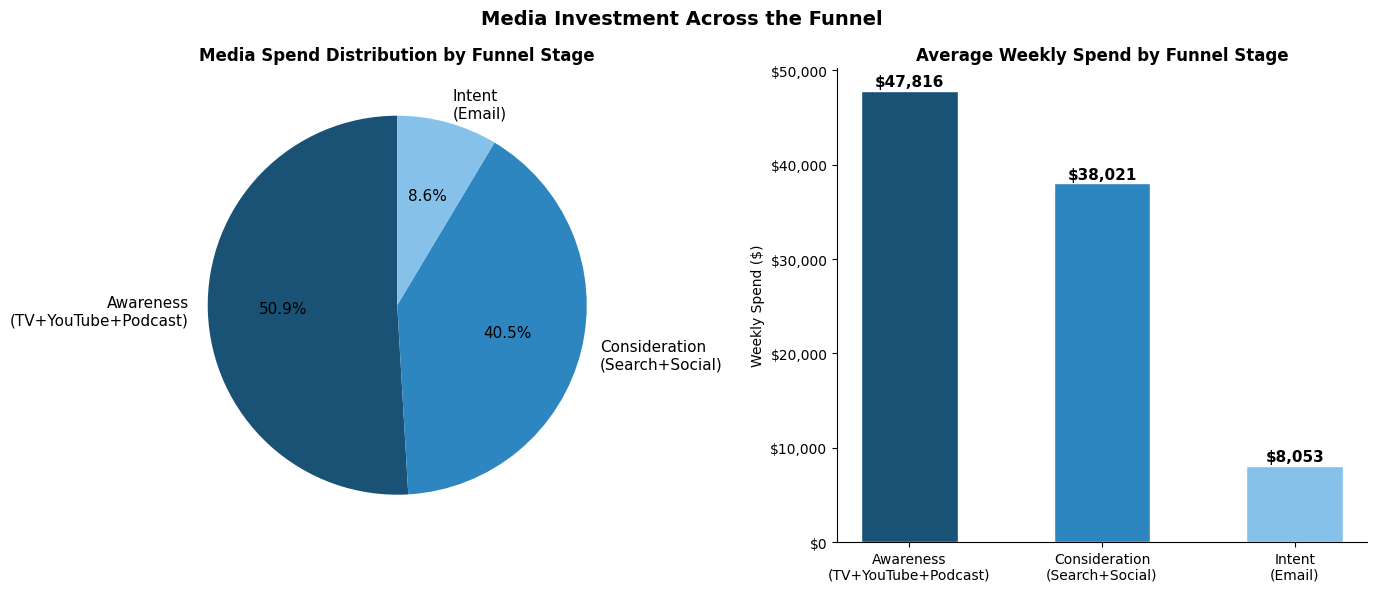

✅ Plot 4 saved!


In [12]:
spend_data = {
    'Awareness\n(TV+YouTube+Podcast)':  awareness['total_spend'].mean(),
    'Consideration\n(Search+Social)':    consideration['total_spend'].mean(),
    'Intent\n(Email)':                   intent['email_spend'].mean()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(spend_data.values(),
            labels=spend_data.keys(),
            colors=[COLORS['awareness'],
                    COLORS['consideration'],
                    COLORS['intent']],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Media Spend Distribution by Funnel Stage',
                  fontweight='bold', fontsize=12)

# Bar chart
axes[1].bar(spend_data.keys(), spend_data.values(),
            color=[COLORS['awareness'],
                   COLORS['consideration'],
                   COLORS['intent']],
            edgecolor='white', width=0.5)
for i, (label, val) in enumerate(spend_data.items()):
    axes[1].text(i, val + 500, f'${val:,.0f}',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Average Weekly Spend by Funnel Stage',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Weekly Spend ($)')
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Media Investment Across the Funnel',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_spend_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4 saved!")

In [13]:
from google.colab import files
for f in ['01_funnel_volume.png', '02_conversion_rates.png',
          '03_funnel_trends.png', '04_spend_distribution.png']:
    files.download(f)
print("✅ All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All charts downloaded!
